# Biocomputing with Brainoware
### Procedure 1 - Human cortical organoid generation and Brainoware hardware integration
#### 1. Spike sorting with Kilosort4 and functional connectivity calculation (google colab version)
**Author: Huiyu Chu, Hongwei Cai**  
**Date: June 6, 2026**  
**Description**: This notebook provides a step-by-step guide for spike sorting using Kilosort4 in Google Colab, specifically based on "Network Scan" result of cortical organoid attached on the MaxOne MEA. It covers dependency installation, raw data processing, sorting, quality metric computation, curation, and functional connectivity analysis.

## 🚀 Runtime Environment Recommendation
For optimal performance and to ensure successful execution of this notebook, it is highly recommended to select a **GPU** runtime with **High RAM** (greater than 40GB, e.g. H100/A100 with high RAM).

# 1. Install dependencies, download raw file, specify file path and saving folder

In [25]:
import os

# install dependencies
!pip install elephant seaborn
!pip install spikeinterface[full,widgets]
!pip install kilosort
!pip install neo
!pip install networkx[default]
!pip install -U kaleido
!pip install --upgrade plotly>=6.1.1

# download Network Scan raw file
if not os.path.exists('/content/fc_example_data.raw.h5'):
  !wget -O /content/fc_example_data.raw.h5 https://www.dropbox.com/scl/fi/yuw74vcwpnr5bnj7juy1w/fc_example_data.raw.h5?rlkey=0ry7a9fmdssw2b451k6k6l7h1&st=9ffu8ts4&dl=1
else:
  print('fc_example_data.raw.h5 already exists. Skipping download.')

# download libcompression file (required for raw MaxOne MEA file reading) and specify env variable HDF5_PLUGIN_PATH
!mkdir -p /usr/local/hdf5/lib/plugin/
if not os.path.exists('/usr/local/hdf5/lib/plugin/libcompression.so'):
  !wget -O /usr/local/hdf5/lib/plugin/libcompression.so https://www.dropbox.com/scl/fi/tcaom66oc5tal2zmp91vm/libcompression.so?rlkey=cw0secdju8nrq7fgrt8saw3hc&st=fz4xh0kl&dl=1
else:
  print('libcompression.so already exists. Skipping download.')
!export HDF5_PLUGIN_PATH=/usr/local/hdf5/lib/plugin

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
              

In [2]:
import os

file_path = '/content/fc_example_data.raw.h5'
output_folder = '/content/sort_output/'

os.makedirs(output_folder, exist_ok=True)
print(f'Output folder created/ensured: {output_folder}')


Output folder created/ensured: /content/sort_output/


# 2. Spike sorting with Kilosort

In [3]:
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp
import spikeinterface.sorters as ss
import spikeinterface.curation as sc
import spikeinterface.qualitymetrics as sqm
import spikeinterface.exporters as sexp
import spikeinterface as si
import torch
import os

torch.cuda.empty_cache()
# === 1️⃣ Load raw MaxOne MEA data ===
recording = se.read_maxwell(
    file_path=file_path,
    stream_id="well000",
    rec_name="rec0000",
)
print("✅ File reading complete!")
# === 2️⃣ Preprocessing: Convert unsigned digits to signed and Band-pass filtering ===
recording_signed = sp.unsigned_to_signed(recording)
recording_filt = sp.bandpass_filter(recording_signed, freq_min=300, freq_max=6000)
print("✅ File preprocessing complete!")
# === 3️⃣ Run Kilosort4 spike sorter ===
sorting = ss.run_sorter(
    sorter_name="kilosort4",
    recording=recording_filt,
    folder=output_folder,
    remove_existing_folder=True,
)
print("✅ sorting complete!")

/tmp/ipykernel_642/673107360.py:5: DeprecationWarning: The module 'spikeinterface.qualitymetrics' is deprecated and will be removed in 0.105.0.Please use 'spikeinterface.metrics.quality' instead.
  import spikeinterface.qualitymetrics as sqm


✅ File reading complete!
✅ File preprocessing complete!


INFO:kilosort.run_kilosort: 
INFO:kilosort.run_kilosort:Computing preprocessing variables.
INFO:kilosort.run_kilosort:----------------------------------------


The h5 compression library for Maxwell is already located in /root/hdf5_plugin_path_maxwell/libcompression.so!


INFO:kilosort.run_kilosort:N samples: 6000800
INFO:kilosort.run_kilosort:N seconds: 300.04
INFO:kilosort.run_kilosort:N batches: 101
INFO:kilosort.run_kilosort:Preprocessing filters computed in 2.21s; total 2.21s
DEBUG:kilosort.run_kilosort:hp_filter shape: torch.Size([30122])
DEBUG:kilosort.run_kilosort:whiten_mat shape: torch.Size([1002, 1002])
DEBUG:kilosort.run_kilosort:First batch min, max: (np.float32(-216.21971), np.float32(55.492023))
INFO:kilosort.run_kilosort: 
INFO:kilosort.run_kilosort:Resource usage after preprocessing
INFO:kilosort.run_kilosort:********************************************************
INFO:kilosort.run_kilosort:CPU usage:    20.40 %
INFO:kilosort.run_kilosort:Mem used:      2.50 %     |       4.24 GB
INFO:kilosort.run_kilosort:Mem avail:    162.81 / 167.05 GB
INFO:kilosort.run_kilosort:------------------------------------------------------
INFO:kilosort.run_kilosort:GPU usage:    46.00 %
INFO:kilosort.run_kilosort:GPU memory:    6.01 %     |      4.76   / 

The h5 compression library for Maxwell is already located in /root/hdf5_plugin_path_maxwell/libcompression.so!
✅ sorting complete!


# 3. Compute required metrics for unit location computing and later curation process

In [4]:
import spikeinterface.qualitymetrics as sqm

# === 4️⃣ Compute quality metrics ===

analyzer = si.create_sorting_analyzer(sorting=sorting, recording=recording_filt, format="memory")
print(analyzer)
analyzer.compute("random_spikes", method="uniform", max_spikes_per_unit=600, seed=2205)
analyzer.compute("waveforms", ms_before=1.3, ms_after=2.6, n_jobs=2)
analyzer.compute("templates", operators=["average", "median", "std"])
analyzer.compute("noise_levels")
# Compute unit locations for all units after waveforms and templates are computed
analyzer.compute("unit_locations")
print(analyzer)

metrics = sqm.compute_quality_metrics(
    analyzer,
    metric_names=["isi_violation", "firing_rate", "snr"],
)

print("✅ metric generation complete!")

estimate_sparsity (no parallelization):   0%|          | 0/301 [00:00<?, ?it/s]

SortingAnalyzer: 1002 channels - 912 units - 1 segments - memory - sparse - has recording
Loaded 0 extensions


compute_waveforms (workers: 2 processes fork):   0%|          | 0/301 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

SortingAnalyzer: 1002 channels - 912 units - 1 segments - memory - sparse - has recording
Loaded 5 extensions: random_spikes, waveforms, templates, noise_levels, unit_locations
✅ metric generation complete!


/usr/local/lib/python3.12/dist-packages/spikeinterface/metrics/quality/misc_metrics.py:209: RuntimeWarning: divide by zero encountered in scalar divide
  snrs[unit_id] = np.abs(amplitude) / noise


In [5]:
print(metrics)

     isi_violations_ratio  isi_violations_count  firing_rate        snr
0                0.181708                     3     4.282762  12.815307
1               42.013583                     2     0.229969  25.630615
2                0.000000                     0     0.766564   6.744899
3                0.000000                     0     1.646447   2.023470
4                0.001681                     2    36.355153  18.211226
..                    ...                   ...          ...        ...
907              0.000000                     0     4.522730  16.187757
908              0.000000                     0     3.952806  18.885716
909              0.268418                    28    10.765231   0.749433
910              0.819725                     3     2.016398  12.140818
911              0.000000                     0     6.329156   8.093878

[912 rows x 4 columns]


In [6]:
analyzer.save_as(
    format="zarr",
    folder=output_folder+"/analyzer/result.zarr"
)

SortingAnalyzer: 1002 channels - 912 units - 1 segments - zarr - sparse - has recording
Loaded 6 extensions: random_spikes, waveforms, templates, noise_levels, unit_locations, quality_metrics

# 4. Curation

In [7]:
# # === 5️⃣ Apply your curation thresholds ===

keep_mask = (metrics["snr"] > 5) & (metrics["isi_violations_ratio"] < 0.3) & (metrics["firing_rate"] > 0.05)
print(keep_mask)

keep_unit_ids = keep_mask[keep_mask].index.values
keep_unit_ids = [unit_id for unit_id in keep_unit_ids]
print(keep_unit_ids)

0       True
1      False
2       True
3      False
4       True
       ...  
907     True
908     True
909    False
910    False
911     True
Length: 912, dtype: bool
[np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(23), np.int64(26), np.int64(27), np.int64(28), np.int64(31), np.int64(32), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(40), np.int64(42), np.int64(44), np.int64(46), np.int64(47), np.int64(49), np.int64(50), np.int64(53), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(64), np.int64(65), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(73), np.int64(74), np.int64(75), np.int64(77), np.int64(81), np.int64(82), np.int64(84), np.int64(86), np.int64(87), np.int64(90), np.int64(91

In [8]:
curated_sorting = sorting.select_units(keep_unit_ids)
print(curated_sorting)
# curated_sorting.save(folder=output_folder+"/curated_sorting")

UnitsSelectionSorting: 616 units - 1 segments - 20.0kHz


In [9]:
import spikeinterface.curation as sc

# drop near-identical spike trains (over-splits / double-counted spikes)
# Update curated_sorting with the result of removing redundant units
curated_sorting = sc.remove_redundant_units(
    curated_sorting,
    align=False,
    remove_strategy="max_spikes",
)

print("✅ Redundant units removed from curated_sorting!")
print(curated_sorting)

✅ Redundant units removed from curated_sorting!
UnitsSelectionSorting: 527 units - 1 segments - 20.0kHz


# 5. Analyze curated units: Locations, Firing Rates, and Spike Trains

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Compute unit locations for curated units ---
# Unit locations have been computed on the original 'analyzer' for all units.
# Now, we extract and filter these locations for the curated units.

# Get all unit locations from the original analyzer
all_unit_locations = analyzer.get_extension("unit_locations").get_data()

# Get the mapping from original unit IDs to their index in all_unit_locations
original_unit_ids = analyzer.sorting.unit_ids
unit_id_to_idx = {uid: i for i, uid in enumerate(original_unit_ids)}

# Get the unit IDs of the curated sorting
curated_unit_ids = curated_sorting.unit_ids

# Get the indices of the curated units within the original unit_locations array
curated_indices = [unit_id_to_idx[uid] for uid in curated_unit_ids]

# Select only the unit locations corresponding to the curated units
unit_locations = all_unit_locations[curated_indices]

print("✅ Unit locations extracted and filtered for curated units!")

✅ Unit locations extracted and filtered for curated units!


In [11]:
# --- 2. Calculate firing rates for curated units ---
unit_ids_curated = curated_sorting.unit_ids
duration_s = recording_filt.get_total_duration()

firing_rates = []
for unit_id in unit_ids_curated:
    spike_train = curated_sorting.get_unit_spike_train(unit_id)
    firing_rate = len(spike_train) / duration_s
    firing_rates.append(firing_rate)

df_firing = pd.DataFrame({
    "unit_id": unit_ids_curated,
    "firing_rate": firing_rates
})

display(df_firing.head())
print("✅ Firing rates calculated for curated units!")

,unit_id,firing_rate
0,0,4.282762
1,2,0.766564
2,4,36.355153
3,6,2.239701
4,7,2.399680


✅ Firing rates calculated for curated units!


In [12]:
# --- 3. Create spike trains table for curated units ---
rows = []
for unit_id in unit_ids_curated:
    spike_times = curated_sorting.get_unit_spike_train(unit_id)
    # Convert spike times to seconds if they are in frames, assuming sampling_rate is available
    # The previous `wNUADjnlW-uR` cell converts to seconds relative to start of unit spike train.
    # Here we need absolute times or keep in frames to match the original structure in context.
    # Let's keep them as frame numbers for now, matching `get_unit_spike_train` output.
    for t in spike_times:
        rows.append({"unit_id": unit_id, "time": t})

df_spikes = pd.DataFrame(rows)

display(df_spikes.head())
print("✅ Spike trains table created for curated units!")

,unit_id,time
0,0,3755
1,0,21027
2,0,34887
3,0,39076
4,0,44314


✅ Spike trains table created for curated units!


In [13]:
# --- 4. Create unit locations table for curated units ---
xy_locations = unit_locations[:, :2] # Assuming unit_locations array has x, y as first two columns
df_locations = pd.DataFrame(xy_locations, columns=["x", "y"])
df_locations.insert(0, "unit_id", unit_ids_curated)

display(df_locations.head())
print("✅ Unit locations table created for curated units!")

,unit_id,x,y
0,0,0.000000,192.500000
1,2,109.181893,496.103608
2,4,132.498800,493.104626
3,6,200.348938,1947.347074
4,7,1811.883336,1484.797065


✅ Unit locations table created for curated units!


In [14]:
# --- 5. Merge dataframes ---
df_merged_curated = pd.merge(df_locations, df_firing, on="unit_id")

display(df_merged_curated.head())
print("✅ Dataframes merged!")

,unit_id,x,y,firing_rate
0,0,0.000000,192.500000,4.282762
1,2,109.181893,496.103608,0.766564
2,4,132.498800,493.104626,36.355153
3,6,200.348938,1947.347074,2.239701
4,7,1811.883336,1484.797065,2.399680


✅ Dataframes merged!


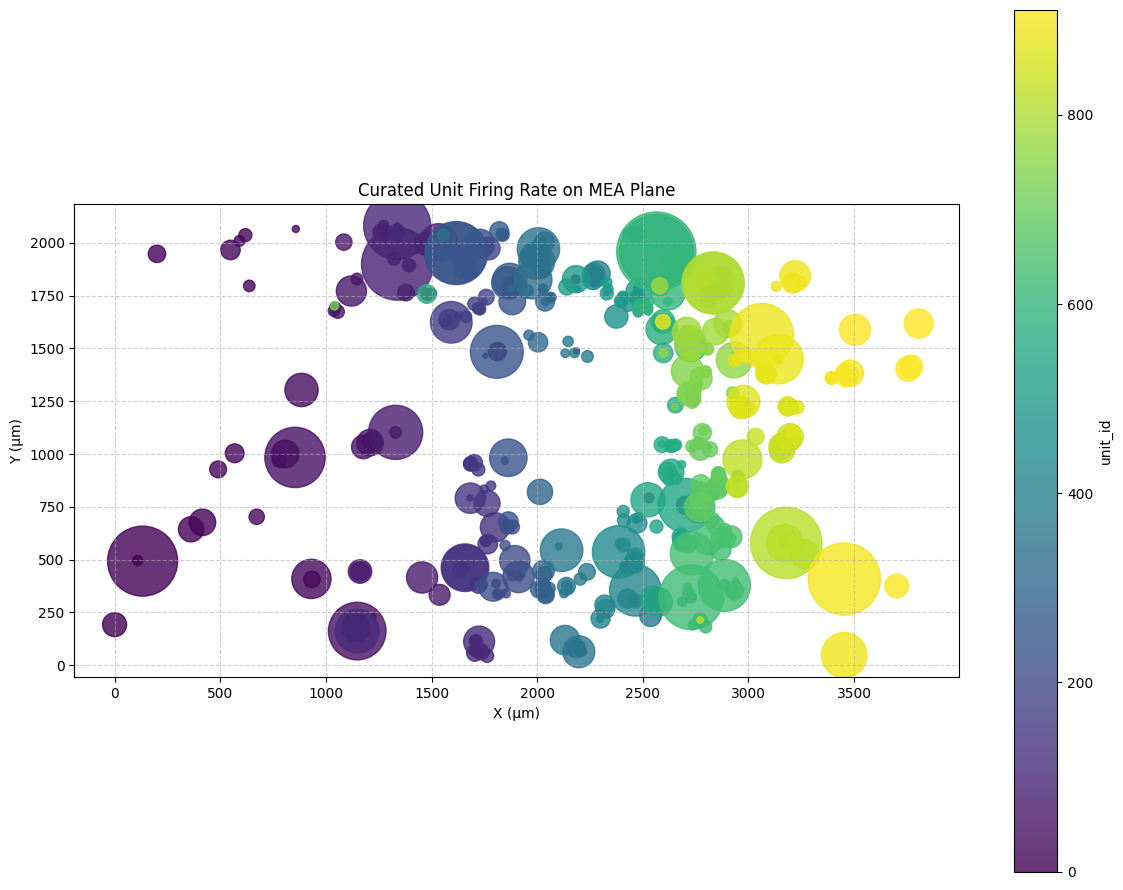

✅ Firing rate map plotted!


In [15]:
# --- 6. Plot firing rate map on the MEA plane ---
fig, ax1 = plt.subplots(figsize=(12, 9))

df_merged_curated.plot.scatter(
    x="x",
    y="y",
    s=df_merged_curated["firing_rate"] * 70, # Scale marker size by firing rate
    c="unit_id", # Color by unit_id
    cmap="viridis", # Using viridis colormap as an example
    alpha=0.8,
    ax=ax1
)
ax1.set_aspect("equal")
ax1.set_ylabel("Y (μm)")
ax1.set_xlabel("X (μm)")
ax1.set_title("Curated Unit Firing Rate on MEA Plane")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("✅ Firing rate map plotted!")

In [16]:
# --- 7. Save outputs ---

# Ensure output_folder is defined from previous cells
# (e.g., '/content/drive/MyDrive/kilosort_results/nature_protocol/sort_output/')

# Create a subfolder for curated results if desired, or save directly
curated_output_folder = os.path.join(output_folder, "curated_analysis")
os.makedirs(curated_output_folder, exist_ok=True)

df_spikes.to_csv(os.path.join(curated_output_folder, "spike_trains_curated.csv"), index=False)
df_merged_curated[["unit_id", "x", "y", "firing_rate"]].to_csv(
    os.path.join(curated_output_folder, "neuron_coord_firing_curated.csv"),
    index=False
)

# Save the plot
fig.savefig(os.path.join(curated_output_folder, "firing_map_curated.svg"), bbox_inches="tight")
fig.savefig(os.path.join(curated_output_folder, "firing_map_curated.png"), bbox_inches="tight")
plt.close(fig) # Close the figure to free up memory

print(f"✅ Curated analysis outputs saved to: {curated_output_folder}")

✅ Curated analysis outputs saved to: /content/sort_output/curated_analysis


# 6 Functional connectivity between sorted neurons

## 6.1 Compute STTC matrix using Neo spiketrain

In [17]:
import pandas as pd

# 1. Prepare unit_df with spike trains (in seconds)
sampling_rate = curated_sorting.get_sampling_frequency()
spike_trains_s = []

for unit in curated_sorting.unit_ids:
    st = curated_sorting.get_unit_spike_train(unit_id=unit)
    # Convert to seconds
    st_s = st / sampling_rate
    spike_trains_s.append(st_s)

unit_df = pd.DataFrame({'unit_id': curated_sorting.unit_ids, 'spike_train': spike_trains_s})

# 2. Merge with df_locations (from section 5) to get accurate unit coordinates
# df_locations has [unit_id, x, y]
unit_loc_spike_train_df = pd.merge(unit_df, df_locations, on='unit_id', how='left')

# Rename columns to match the existing connectivity plotting logic
unit_loc_spike_train_df = unit_loc_spike_train_df.rename(columns={
    'x': 'channel_location_x',
    'y': 'channel_location_y'
})

display(unit_loc_spike_train_df.head())
print("✅ Refactored unit mapping using computed locations!")

,unit_id,spike_train,channel_location_x,channel_location_y
0,0,"[0.18775, 1.05135, 1.74435, 1.9538, 2.2157, 2....",0.000000,192.500000
1,2,"[0.8199, 0.82555, 1.5898, 5.0786, 5.80125, 6.3...",109.181893,496.103608
2,4,"[0.03265, 0.05655, 0.07975, 0.1057, 0.1228, 0....",132.498800,493.104626
3,6,"[1.12035, 1.7416, 2.21115, 2.2557, 2.27055, 2....",200.348938,1947.347074
4,7,"[0.04535, 0.35005, 1.68975, 2.25875, 3.8043, 3...",1811.883336,1484.797065


✅ Refactored unit mapping using computed locations!


In [18]:
# Define fast STTC functions using Numba
import numpy as np
from numba import njit


@njit
def proportion_in_window(spikes_1, spikes_2, dt):
    """Fraction of spikes_1 that have a spikes_2 spike within +/- dt."""
    count = 0
    n1 = len(spikes_1)
    n2 = len(spikes_2)
    idx2 = 0
    for i in range(n1):
        t = spikes_1[i]
        while idx2 < n2 and spikes_2[idx2] < t - dt:
            idx2 += 1
        if idx2 < n2 and abs(spikes_2[idx2] - t) <= dt:
            count += 1
    return count / n1 if n1 > 0 else 0.0


@njit
def compute_sttc_matrix(spike_trains, dt, T):
    """Symmetric STTC matrix for a list of sorted spike trains (sample units)."""
    n = len(spike_trains)
    sttc_matrix = np.full((n, n), np.nan)
    for i in range(n):
        sa = spike_trains[i]
        TA = (2 * dt * len(sa)) / T
        for j in range(i + 1, n):
            sb = spike_trains[j]
            TB = (2 * dt * len(sb)) / T

            PA = proportion_in_window(sb, sa, dt)
            PB = proportion_in_window(sa, sb, dt)

            denom_a = 1 - TA
            denom_b = 1 - TB
            if denom_a > 0 and denom_b > 0:
                sttc = 0.5 * ((PA - TB) / denom_a + (PB - TA) / denom_b)
                sttc_matrix[i, j] = sttc
                sttc_matrix[j, i] = sttc
    return sttc_matrix


In [19]:
# --- Optimized STTC Calculation with Consistency ---
# Using the Numba functions defined in KjdSWIB4xftR

# 1. Define parameters (consistent with section 6.2 defaults)
lag_s = 0.030
sampling_rate = curated_sorting.get_sampling_frequency()
dt_samples = int(lag_s * sampling_rate)

# 2. Get total recording duration in samples
duration_samples = recording_filt.get_num_samples()

# 3. Prepare the typed list of spike trains (in samples) for Numba
from numba.typed import List

# We use the curated_sorting to ensure we are only analyzing approved units
spike_trains_samples_list = List()
for unit_id in curated_sorting.unit_ids:
    st_samples = curated_sorting.get_unit_spike_train(unit_id).astype(np.float64)
    spike_trains_samples_list.append(st_samples)

print(f"Calculating accelerated STTC for {len(spike_trains_samples_list)} units...")

# 4. Compute the matrix
# Using the function: compute_sttc_matrix(spike_trains, dt, T)
sttc_result = compute_sttc_matrix(spike_trains_samples_list, dt_samples, float(duration_samples))

# 5. Consistency: Replace NaN with 0 and assign to 'adjM' for downstream plotting
adjM = np.nan_to_num(sttc_result, nan=0.0)

print("✅ STTC matrix (adjM) calculated successfully using Numba!")
display(pd.DataFrame(adjM).head())

Calculating accelerated STTC for 527 units...
✅ STTC matrix (adjM) calculated successfully using Numba!


,0,1,2,3,4,5,6,7,8,9,...,517,518,519,520,521,522,523,524,525,526
0,0.000000,-0.102218,0.0,0.046004,-0.011737,-0.137001,-0.137661,-0.022538,-0.008986,0.130170,...,0.0,0.009153,-0.001933,-0.036640,-0.065739,-0.234797,-0.147178,-0.096503,-0.112984,-0.257841
1,-0.102218,0.000000,0.0,-0.063304,-0.010125,-0.103495,0.235122,-0.022609,-0.011155,-0.020194,...,0.0,-0.023229,-0.028647,0.016536,-0.007011,-0.119403,-0.036720,-0.108388,-0.035947,-0.144011
2,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.046004,-0.063304,0.0,0.000000,0.165948,-0.070677,-0.043526,-0.014846,0.059735,0.034072,...,0.0,0.039840,-0.006399,0.011830,-0.038964,-0.150145,-0.077232,0.028413,-0.108075,-0.057078
4,-0.011737,-0.010125,0.0,0.165948,0.000000,-0.121614,0.029399,0.072303,-0.027191,-0.020031,...,0.0,0.041956,0.049200,0.048632,0.016605,-0.166124,-0.078647,-0.060753,-0.026087,-0.107263


## 6.2 Plot the matrix in the electrode plane

In [20]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
def cluster_corr(corr_array, inplace=False):
    """
    Rearranges the correlation matrix, corr_array, so that groups of highly
    correlated variables are next to eachother

    Parameters
    ----------
    corr_array : pandas.DataFrame or numpy.ndarray
        a NxN correlation matrix

    Returns
    -------
    pandas.DataFrame or numpy.ndarray
        a NxN correlation matrix with the columns and rows rearranged
    """
    pairwise_distances = sch.distance.pdist(corr_array)
    linkage = sch.linkage(pairwise_distances, method="complete")
    cluster_distance_threshold = pairwise_distances.max() / 2
    idx_to_cluster_array = sch.fcluster(
        linkage, cluster_distance_threshold, criterion="distance"
    )
    idx = np.argsort(idx_to_cluster_array)

    if not inplace:
        corr_array = corr_array.copy()

    if isinstance(corr_array, pd.DataFrame):
        return corr_array.iloc[idx, :].T.iloc[idx, :]
    return corr_array[idx, :][:, idx]

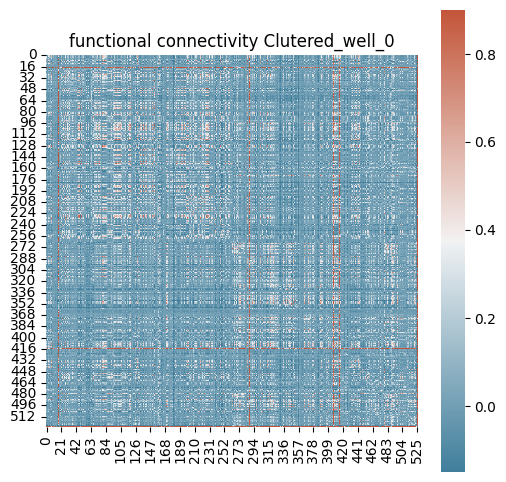

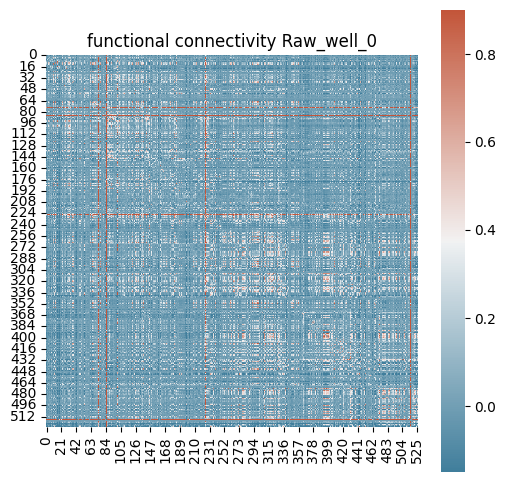

In [23]:
import seaborn as sns

path = output_folder

path_save = (
    path
    + "/functional_connectivity/"
)
if not os.path.exists(path_save):
  os.mkdir(path_save)

well = "well_0"
lag = 0.03
color_total = 8
width_total = 5
dw = 2
thred_c = 0.3
thred_delta = 0.3
thred_plot = 0.15
firing_min = 0.05
connection_type = "s"
svg_output = "y"  # y for save, n for not save svg images
csv_output = "y"
color_map_s = "RdYlGn_r"
color_map_w = "GnBu"  # w for weaken, s for strenghthen
node_colors = ["mediumseagreen"]
heatmap_max = 0.9
heatmap_min = -0.15
filename = "functional connectivity"
# Matrix heatmap
fig_0, ax_0 = plt.subplots(figsize=(6, 6))
cmap_heatmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(
    cluster_corr(adjM),
    vmin=heatmap_min,
    vmax=heatmap_max,
    cmap=cmap_heatmap,
    square=True,
    ax=ax_0,
)
plt.title(f"{filename} Clutered_" + well)
if svg_output == "y":
    plt.savefig(
        path_save
        + "heatmap(clustered)_fig_"
        + filename
        + "_"
        + well
        + ".svg"
    )
fig_1, ax_1 = plt.subplots(figsize=(6, 6))
sns.heatmap(
    adjM,
    cmap=cmap_heatmap,
    vmin=heatmap_min,
    vmax=heatmap_max,
    square=True,
    ax=ax_1,
)
plt.title(f"{filename} Raw_" + well)
if svg_output == "y":
    plt.savefig(
        path_save
        + "heatmap(raw)_fig_"
        + filename
        + "_"
        + well
        + ".svg"
    )

In [31]:
import networkx as nx
import plotly.graph_objects as go
import matplotlib.colors as mc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

network_index = []
network_all = []
width_total = 3
thred_c = 0.3
# Updated cmap handling for modern Matplotlib
if connection_type == "w":
    cmap = plt.colormaps.get_cmap(color_map_w)
    node_color = node_colors[0]
else:
    cmap = plt.colormaps.get_cmap(color_map_s)
    node_color = node_colors[0]

color_map = []
for i in range(0, color_total):
    a = cmap(i / color_total)
    a = mc.to_hex(a, keep_alpha=False)
    color_map.append(a)

widths = np.arange(0, dw * width_total, dw) + 1
for i in range(0, width_total):
    widths[i] = (widths[i] / 2) ** 2

def make_edge(x, y, text, width, colors):
    return go.Scatter(
        x=x,
        y=y,
        line=dict(width=width, color=colors),
        hoverinfo="text",
        text=([text]),
        mode="lines",
    )

# threshold processing
np_delta = np.where(adjM < thred_c, 0, adjM)
np_nzero = np.where(adjM < 0, 0, adjM)
nx_all = nx.from_numpy_array(np_nzero)
nx_delta = nx.from_numpy_array(np_delta)

np_coord = unit_loc_spike_train_df.loc[:, ["channel_location_x", "channel_location_y"]]
np_coord = np_coord.to_numpy()

midsummer = nx_delta
pos_ = np_coord

edge_trace = []
for edge in midsummer.edges():
    weight = midsummer.edges()[edge]["weight"]
    if weight > 0:
        char_1 = edge[0]
        char_2 = edge[1]
        x0, y0 = pos_[char_1]
        x1, y1 = pos_[char_2]

        color_idx = int(((weight - thred_plot) / (1 - thred_plot) * (color_total - 1)))
        width_idx = int(((weight - thred_plot) / (1 - thred_plot) * (width_total - 1)))

        color_idx = max(0, min(color_total - 1, color_idx))
        width_idx = max(0, min(width_total - 1, width_idx))

        trace = make_edge(
            [x0, x1, None],
            [y0, y1, None],
            None,
            widths[width_idx],
            color_map[color_idx],
        )
        edge_trace.append(trace)

node_trace = go.Scatter(
    x=[],
    y=[],
    text=[],
    textposition="top center",
    textfont_size=10,
    mode="markers+text",
    hoverinfo="text",
    marker=dict(color=[], size=[], line=None),
)

for i, node in enumerate(midsummer.nodes()):
    x, y = pos_[node]
    unit_id = unit_loc_spike_train_df.iloc[i]['unit_id']
    node_trace["x"] += tuple([x])
    node_trace["y"] += tuple([y])
    node_trace["marker"]["color"] += tuple([node_color])
    node_trace["marker"]["size"] += tuple([2 * (sum(np_delta[:, node])) ** (1 / 2)])
    #node_trace["text"] += tuple([f"Unit {unit_id}"])

layout = go.Layout(
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    width=1200,
    height=800,
    title=f"{filename} network_" + well,
)

fig = go.Figure(layout=layout)
for trace in edge_trace: fig.add_trace(trace)
fig.add_trace(node_trace)
fig.update_layout(showlegend=False)
fig.update_yaxes(autorange="reversed")
fig.show()